In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("/home/admin1/twitter_training.csv",header=None)

print(df.head())

      0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [4]:
print(df.columns)

Index([0, 1, 2, 3], dtype='int64')


In [5]:
df.columns = ['id', 'game', 'label', 'text']

In [6]:
df = df[['text', 'label']]

In [7]:
df['label'] = df['label'].map({
    'Positive': 1,
    'Negative': -1,
    'Neutral': 0
})

In [8]:
df = df.dropna()

In [9]:
print(df.head())

                                                text  label
0  im getting on borderlands and i will murder yo...    1.0
1  I am coming to the borders and I will kill you...    1.0
2  im getting on borderlands and i will kill you ...    1.0
3  im coming on borderlands and i will murder you...    1.0
4  im getting on borderlands 2 and i will murder ...    1.0


In [10]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [12]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

In [13]:
y_pred = model.predict(X_test_vec)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7195092024539878

Classification Report:
               precision    recall  f1-score   support

        -1.0       0.70      0.82      0.76      4427
         0.0       0.76      0.57      0.65      3678
         1.0       0.71      0.75      0.73      4120

    accuracy                           0.72     12225
   macro avg       0.73      0.71      0.71     12225
weighted avg       0.72      0.72      0.72     12225



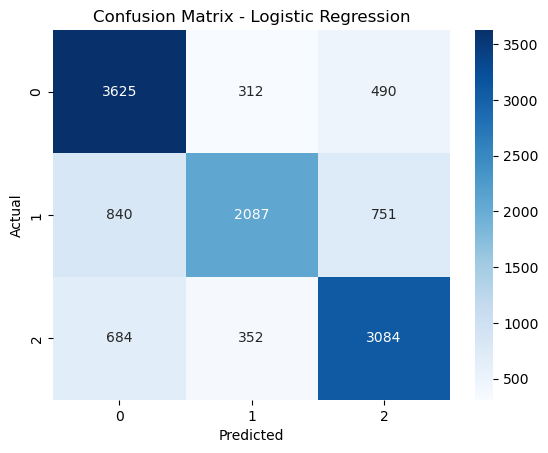

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
CM = confusion_matrix(y_test, y_pred)
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### REDDIT Dataset

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("/home/admin1/Reddit_Data.csv")
df

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [24]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [27]:
df.dropna(inplace=True)

In [28]:
df.isnull().sum()

clean_comment    0
category         0
dtype: int64

In [29]:
df['category'].value_counts()

category
 1    15830
 0    13042
-1     8277
Name: count, dtype: int64

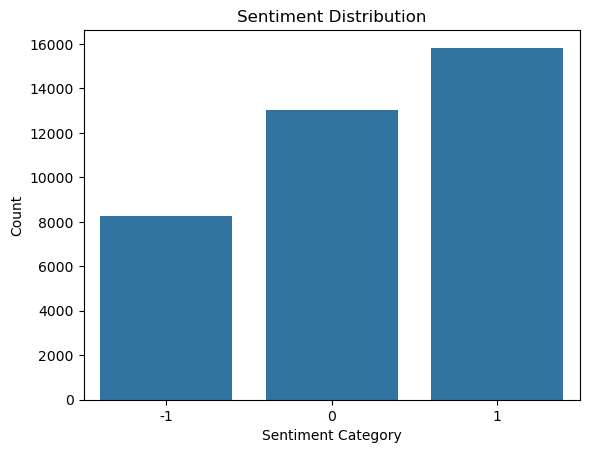

In [31]:
sns.countplot(x=df['category'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Count")

plt.show()

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(df['clean_comment'])
y = df['category']

In [35]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2)

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [37]:
from sklearn.naive_bayes import MultinomialNB

NB = MultinomialNB()
NB.fit(x_train, y_train)

y_pred_NB = NB.predict(x_test)
print("NAIVE BAYES RESULTS ->\n")

print("Accuracy : ", accuracy_score(y_test, y_pred_NB))
print("Precision : ", precision_score(y_test, y_pred_NB, average='weighted'))
print("Recall : ", recall_score(y_test, y_pred_NB, average='weighted'))
print("F1 Score : ", f1_score(y_test, y_pred_NB, average='weighted'))

NAIVE BAYES RESULTS ->

Accuracy :  0.5405114401076716
Precision :  0.7279676731089483
Recall :  0.5405114401076716
F1 Score :  0.4645863594379338


In [38]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier()
RF.fit(x_train, y_train)

y_pred_RF = RF.predict(x_test)
print("RANDOM FOREST RESULTS ->\n")

print("Accuracy : ", accuracy_score(y_test, y_pred_RF))
print("Precision : ", precision_score(y_test, y_pred_RF, average='weighted'))
print("Recall : ", recall_score(y_test, y_pred_RF, average='weighted'))
print("F1 Score : ", f1_score(y_test, y_pred_RF, average='weighted'))

RANDOM FOREST RESULTS ->

Accuracy :  0.7722745625841184
Precision :  0.7967114525832277
Recall :  0.7722745625841184
F1 Score :  0.7441239774541181


In [39]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=500)
LR.fit(x_train, y_train)

y_pred_LR = LR.predict(x_test)
print("LOGISTIC REGRESSION RESULTS ->\n")

print("Accuracy : ", accuracy_score(y_test, y_pred_LR))
print("Precision : ", precision_score(y_test, y_pred_LR, average='weighted'))
print("Recall : ", recall_score(y_test, y_pred_LR, average='weighted'))
print("F1 Score : ", f1_score(y_test, y_pred_LR, average='weighted'))

LOGISTIC REGRESSION RESULTS ->

Accuracy :  0.8546433378196501
Precision :  0.8586248284993354
Recall :  0.8546433378196501
F1 Score :  0.8509235669527835


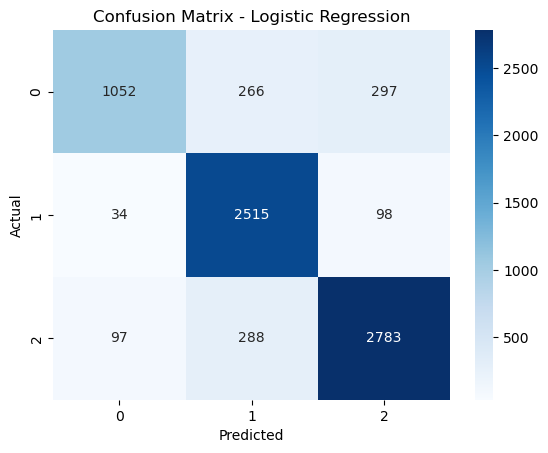

In [40]:
from sklearn.metrics import confusion_matrix

CM = confusion_matrix(y_test, y_pred_LR)
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

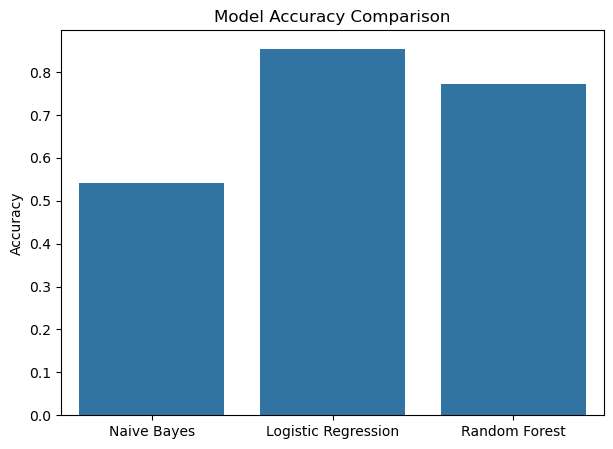

In [41]:
models = ['Naive Bayes','Logistic Regression','Random Forest']

accuracies = [accuracy_score(y_test, y_pred_NB), accuracy_score(y_test, y_pred_LR), accuracy_score(y_test, y_pred_RF)]

plt.figure(figsize=(7,5))
sns.barplot(x=models, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()